# 7 - Structure Functions

This tutorial covers the basics on a self-contained synthetic field, while Tutorial [TBD] will apply it to real data.

## Calculating a Structure Function

The second-order structure function,

$$S_2(\ell) = \langle\, [f(x+\ell) - f(x)]^2 \,\rangle,$$

measures how a field $f$ (e.g. a velocity residual map) decorrelates with separation $\ell$. It rises from zero at small lag to a plateau of $2\sigma^2$ once points are uncorrelated, and the lag of the rollover encodes the correlation scale.

`eddy` computes a *2D* structure function on a polar `(radius, azimuth)` grid — axis 0 is radius, axis 1 is azimuth — and can either pool the whole field or resolve the result by reference radius. There are two things to build:

- **`calculate_structure_function(field, ...)`** returns a **`StructureFunction`**: a single 2D $S_2$ surface. The default `ref_i=-1` pools *every* pair in the field into one *global* $S_2$; setting `ref_i` to a row index instead anchors every pair to that reference annulus.
- **`calculate_structure_function_stack(field, ref_rs, ...)`** returns a **`StructureFunctionStack`**: one reference-anchored `StructureFunction` per radius in `ref_rs`, in a list-like container.

Each calculation has three spellings, differing only in what you start from:

| starting from | global $S_2$ | stack |
|---|---|---|
| a bare polar array | `calculate_structure_function` | `calculate_structure_function_stack` |
| ... same, as a classmethod | `StructureFunction.calculate` | `StructureFunctionStack.calculate` |
| a sky map | `momentmap.calculate_structure_function` | `momentmap.calculate_structure_function_stack` |

The `momentmap` route deprojects onto the polar grid first (via `imagecube.polar_deprojection`), so it takes the usual geometry arguments (`inc`, `PA`, `x0`, `y0`, `z0`, ...) and its lag axes are radial lag [arcsec] and azimuthal lag [deg]. The stack variant deprojects **once** and shares the grid across all `ref_rs`.

The bare-array routes take a **`grid`** argument declaring what you handed them, because the kernel itself is just a regular-grid lag estimator and cannot tell the two cases apart:

- **`grid="polar"`** (the default) — the `imagecube.polar_deprojection` layout: axis 0 = radius [arcsec], axis 1 = azimuth [deg]. Pass an *already deprojected* field. The two axes are incommensurate, so the azimuthally-averaged `S2_i` is suppressed (`None`), and the radius/azimuth analyses are available.
- **`grid="cartesian"`** — any grid whose two axes share units: a sky-plane image, or a simulation slice. `S2_i` is meaningful and returned; `fit_GRF`, `fit_spiral`, `calculate_heuristics` and the heatmaps raise instead of returning numbers with no physical meaning.

The geometry is recorded on the result as `.grid` and carried through `combine`, `subtract` and `collapse`; mixing a polar and a Cartesian $S_2$ raises.

To work with many realizations of a field, **`calculate_structure_function_ensemble(fields, mode=...)`** returns a *list* of results — one per realization, deliberately **not** averaged — so you can take the scatter across the realization axis. Use `mode="global"` for one `StructureFunction` per field, or `mode="stack"` for one `StructureFunctionStack` per field.

### What the objects hold

A `StructureFunction` carries the 2D surface `S2` with its pair `counts`, the on-axis slices `S2_x` (radial) and `S2_y` (azimuthal), the matching lag axes `lags_x` / `lags_y`, and grid metadata (`dx`, `dy`, `grid`, `ref`, `x_grid`, `y_grid`, `extent`, ...). On a Cartesian grid it also carries the azimuthally-averaged profile `S2_i` on its own `lags_i` axis.

A `StructureFunctionStack` is list-like over its per-radius results (`len()`, indexing, iteration) and also exposes them stacked along a leading radius axis: `S2_stack`, `S2_x_stack`, `S2_y_stack`, `S2_i_stack`, `counts_x_stack`, ..., alongside the `ref_rs` it was built at.

## Analyzing $S_2$

Some analyses apply to both objects; others only make sense for the global `StructureFunction` or only for the `StructureFunctionStack`.

### Universal Functions

- **`fit_GRF(...)`** fits the anisotropic Gaussian-random-field parameterization, in which the correlation lengths scale as power laws, $\ell_r(r) = \ell_{0,r}\,(r/r_0)^{\alpha_r}$ and $\ell_\phi(r) = \ell_{0,\phi}\,(r/r_0)^{\alpha_\phi}$ (arc length), over a plateau of $2\sigma^2$. The fitted set is $\theta = \{\sigma,\, \ell_{0,r},\, \ell_{0,\phi},\, \alpha_r\}$, with $\alpha_\phi$ **tied to $\alpha_r$** (a radius-independent anisotropy) unless `fit_alphaphi=True` frees it. Both a LSQ optimization (`method='lsq'`, with a Gauss-Newton covariance) and an `emcee`-based posterior estimation (`method='mcmc'`, with an optional `jitter` nuisance) can be performed. The anisotropy $\mathcal{A} = \ell_\phi/\ell_r$ is derived, not fit.
- **`fit_spiral(modes=...)`** fits the azimuthal slice with the multi-mode periodic model `S2phi`, $N_\phi + \sum_m A_m^2\,[1 - \cos(m\,\Delta\phi)]$.
- **`subtract(other)`** removes a noise model at the $S_2$ level — structure functions of independent components add, so a noise contribution subtracts.
- **`combine(others)`** pair-count-weighted average over realizations.

### `StructureFunction` Only

- **`fit_GRF(pitch=True)`** additionally frees `pitch` [deg], the tilt of the correlation ellipse away from the azimuthal direction. This is only measurable in **global mode** (built with `ref_i=-1`, and passing `r_axis`): the antisymmetric off-diagonal ridge is the unique pitch signature, and both the on-axis slices and a reference-annulus surface average it away. Calling it anywhere else raises.
- **`plateau()`**, **`half_power_lag(axis)`** and **`reliability_weight()`** reduce the result to scalars: the $2\sigma^2$ asymptote, a model-free correlation scale, and a weight for cross-radius averages.
- **`compare_to(other)`** and **`plot_comparison(other)`** difference two $S_2$ on a shared grid.
- **`plot_2d()`** and **`plot_profiles()`** draw the surface and its slices.

### `StructureFunctionStack` Only

- **`calculate_heuristics()`** returns the six model-free scalars $\{\hat{\sigma},\, \hat{\ell}_r,\, \hat{\ell}_\phi,\, \hat{\mathcal{A}},\, \hat{\alpha}_r,\, \hat{\alpha}_\phi - 1\}$ (`T1a`, `T1b`, `T1c`, `T2`, `T3`, `T4`), measured per ring and averaged with the `neff` reliability weights. They map onto the `fit_GRF` parameters but are measurements, not a fit. Two conventions to watch: `T4` is the slope of $\log \ell_\phi\,[\mathrm{deg}]$ against $\log r$, so it equals $\hat{\alpha}_\phi - 1$ and **not** $\hat{\alpha}_\phi$ (kept this way because it needs no multiply by the deprojection-uncertain ring radius); and `rescale_returns=False` returns the raw $\{2\sigma^2, \log\mathcal{A}\}$ in place of $\{\hat{\sigma}, \hat{\mathcal{A}}\}$. Restrict the rings entering every average with `r_min` / `r_max`.
- **`calculate_modal_power()`** fits an azimuthal cut at each reference radius with the periodic model above and converts the amplitudes into power, revealing which low-order $m$ modes dominate the azimuthal variance. `plot_modal_power()` draws it.
- **`collapse()`** pools the radius axis (pair-count-weighted) back down to a single `StructureFunction`.
- **`plateaus()`**, **`half_power_lags()`**, **`reliability_weights()`** are the per-annulus forms of the scalar summaries.
- **`calculate_azimuthal_heatmap()`**, **`calculate_radial_heatmap()`** and **`calculate_anisotropy_heatmap()`** (each with a `plot_` counterpart) show how the structure varies with radius; **`calculate_pairwise_error_heatmaps()`** gives their uncertainties, **`evaluate_spiral_heatmap()`** overlays a fitted spiral model, and **`plot_gridded()`** shows the underlying deprojected field.

### Forward Models

The parametric $S_2$ can also be evaluated without any data, for prediction or for injection tests: `grf_s2_slices` and `grf_s2_2d_global` (the GRF model that `fit_GRF` fits), `predict_s2_slices` / `predict_s2_2d` (the same, plus an optional deterministic spiral), `predict_spiral_s2_slices` / `predict_spiral_s2_2d` (spiral only), the correlation-length laws `ell_r` / `ell_phi`, the azimuthal model `S2phi`, and `gaussian_beam_s2` for the analytic beam-noise $S_2$.

An empirical noise model can be built straight from the cube instead: `linecube.noise_structure_function()` averages $S_2$ over signal-free channels, `linecube.gaussian_beam_s2()` matches the analytic prediction to it, and `linecube.spectral_acf()` checks for an oversampled spectral axis first.

### Drawing Realizations

The inverse of measuring an $S_2$ — useful for injection/recovery tests and for noise nulls. Which route you want depends on what you are drawing *from*:

- **`draw_polar_field(r, phi, ...)`** draws the anisotropic GRF from its **parameters**, i.e. the same field the `fit_GRF` forward models describe. Build the grid with `make_polar_grid(r_min, r_max, n_r, n_phi)`. Two backends: `method="exact"` factors the full Paciorek–Schervish covariance (`polar_covariance`) and is limited to modest grids by its $O(N^3)$ cost, while `method="convolution"` (the default) uses a spatially-varying Gaussian process-convolution that targets the same covariance in the continuum limit, never forms an $N \times N$ matrix, and scales to full-resolution grids. Pass `mean=` to add a deterministic component. This is the route for injection/recovery: draw at known $\theta$, measure $S_2$, refit, compare.
- **`StructureFunction.draw_realization()`** draws from a **measured** $S_2$ by Wiener–Khinchin spectral synthesis — one FFT per draw, so it is cheap enough for large Monte-Carlo ensembles, and it reproduces the full correlated structure of a real imaged noise field rather than just a beam model. It requires `grid="cartesian"`, because spectral synthesis assumes stationarity: a polar $S_2$ has correlation lengths that grow with radius, and synthesizing from it would silently launder that away. Negative power-spectrum bins (a finite, noisy $S_2$ is not positive-definite) are clipped to zero, which *adds* variance, so the method warns when the clipped fraction gets large — average more realizations into the input $S_2$ if it does.

### Still to Come

- **`winding_contrast()`** — scan the $S_2$ for the optimal winding angle. Open question: whether this needs a `StructureFunction` built on a $(\ln r, \phi)$ grid, in which a constant-pitch spiral is a straight line and the self-similar GRF ($\alpha_r = 1$, $\alpha_\phi = 1$) is stationary.

# EVERYTHING BELOW HERE IS THE TRUE TUTORIAL

# An Introduction to Structure Functions

The second-order structure function of a field $f$ is the mean square difference between pairs of points separated by a lag $\boldsymbol{\ell}$,

$$S_2(\boldsymbol{\ell}) \;=\; \big\langle\, [\,f(\mathbf{x} + \boldsymbol{\ell}) - f(\mathbf{x})\,]^2 \,\big\rangle_{\mathbf{x}},$$

where the average runs over every pair in the map with that separation. For a zero-mean field of variance $\sigma^2$ and normalized autocorrelation $\rho$ this expands to

$$S_2(\boldsymbol{\ell}) \;=\; 2\sigma^2\,\big[\,1 - \rho(\boldsymbol{\ell})\,\big],$$

so $S_2$ carries the same information as the autocorrelation function, written so that it vanishes where the field is perfectly correlated. There are three important properties that we can leverage in our analysis.

- $S_2 \to 0$ as $\ell \to 0$: Neighbouring points are identical.
- $S_2 \to 2\sigma^2$ at large $\ell$: The amplitude of the flucutations can be determined as $\sigma = \sqrt{S_2^{\rm plateau}/2}$.
- The correlation length, $\ell_0$, defines where $S_2$ transitions for correaltion to no correlation.

For a Gaussian correlation, $\rho = \exp(-\ell^2/2\ell_0^2)$, the shape is fully specified,

$$S_2(\ell) = 2\sigma^2\left[1 - e^{-\ell^2/2\ell_0^2}\right],$$

and it reaches half of its plateau at $\ell = \sqrt{2\ln 2}\,\ell_0 \approx 1.18\,\ell_0$. That factor relates every *half-power lag* below to the $\ell_0$ it is measuring, so it is worth keeping in view.

**Why this rather than a power spectrum?** $S_2$ is a pair statistic, so it needs neither a periodic box nor a filled aperture: masked pixels, a central hole and a ragged outer edge simply remove pairs instead of ringing through an entire transform. It is also *local* — restrict the pairs to an annulus and you have $S_2$ for that annulus — which is what lets a radially varying disk be characterized radius by radius. And because structure functions of statistically independent components add, an $S_2$ measured on signal-free channels is a noise model that can be subtracted from one measured on the signal.

The cost is that a lag in a disk is not one number. `eddy` therefore keeps $S_2$ as a **2D** surface on the deprojected polar grid, with a radial lag $\ell_r$ in arcsec and an azimuthal lag $\Delta\phi$ (deg). However, it must be remembered that the two lag axes are **not interchangeable**. One is a length, the other an angle. That is why the azimuthally averaged profile `S2_i` is switched off on a polar grid, and why turning $\Delta\phi$ into an arc length $r\,\Delta\phi$ always drags a radius into the answer. Furthermore, disk fluctuations are generically **anisotropic** (sheared into arcs) and **non-stationary** (correlation lengths growing outwards). Therefore we care about the overall structure of $S_2$ rather than specific values pulled from this.

In [1]:
# standard imports

import numpy as np
import matplotlib.pyplot as plt

from eddy import (make_polar_grid,
                  draw_polar_field,
                  calculate_structure_function,
                  calculate_structure_function_ensemble)

# The parametric forward models and the correlation-length laws are not
# re-exported at the top level, so come from the submodule directly.
from eddy.structurefunction import ell_r, ell_phi, grf_s2_slices

HALF_POWER = np.sqrt(2.0 * np.log(2.0))

## Building Intuition - Noise

To understand how a structure function looks and behaves, we start with the simplest possible field: **isotropic** and **stationary**.

In `eddy`'s parameterization both correlation lengths are power laws in radius,

$$\ell_r(r) = \ell_{0,r}\left(\frac{r}{r_0}\right)^{\alpha_r}, \qquad \ell_\phi(r) = \ell_{0,\phi}\left(\frac{r}{r_0}\right)^{\alpha_\phi},$$

with both in arcsec — $\ell_\phi$ as an **arc length**, not an angle. So

- *isotropic* means $\ell_{0,\phi} = \ell_{0,r}$: the correlation ellipse is a circle;
- *stationary* means $\alpha_r = \alpha_\phi = 0$: the same circle at every radius.

This is also what correlated **noise** looks like. The beam correlates neighbouring pixels over one fixed physical scale everywhere on the map, with no reference to the disk centre.

First, we draw a single realization on a polar grid.

Three things to look for below: circular contours in the 2D $S_2$, a plateau at $2\sigma^2$, and a rollover at $1.18\,\ell_0$ along both axes. Plus one wrinkle that motivates the rest of the tutorial — a *constant arc length* is a *shrinking angle*, $\ell_\phi[{\rm deg}] \propto \ell_{0,\phi}/r$, so even this field's azimuthal cut depends on radius once the lag is measured in degrees.

A single realization is also only an estimate of $S_2$; 24 are drawn so that one can be compared against all of them pooled.

In [29]:
# define your polar grid

r, phi = make_polar_grid(r_min=0.5, r_max=2.0, n_r=120, n_phi=240)
dr, dphi = np.diff(r)[0], np.degrees(np.diff(phi)[0])

# grid edges for plotting

r_e = np.append(r - 0.5 * dr, r[-1] + 0.5 * dr)
p_e = np.radians(np.append(np.degrees(phi) - 0.5 * dphi,
                           np.degrees(phi[-1]) + 0.5 * dphi))

# draw a correlated field with a standard deviation of 20 m/s
# note that we draw 24 realizations of this

noise_truth = dict(sigma=20.0,
                   ell0r=0.15,
                   ell0phi=0.15,
                   alphar=0.0,
                   alphaphi=0.0,
                   r0=1.0,
                   )

noise = draw_polar_field(r, phi, n_realizations=24, **noise_truth)

We can plot them to see how they look. Note that we set the `vmin` and `vmax` to $60~{\rm m\,s^{-1}} = 3\sigma$.

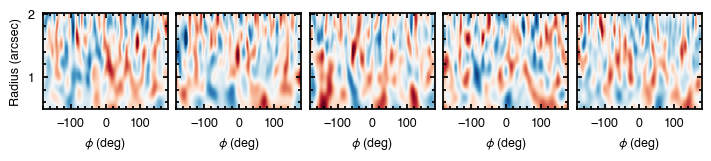

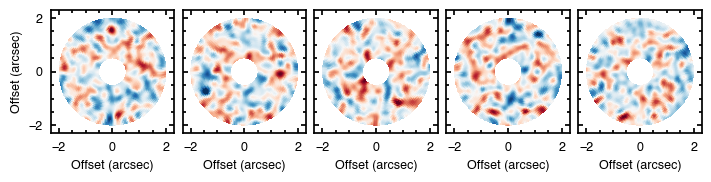

In [ ]:
# in polar projection

fig, axs = plt.subplots(ncols=5, figsize=(7, 1.5), constrained_layout=True)
for noise_draw, ax in zip(noise, axs):
    im = ax.pcolormesh(np.degrees(p_e), r_e, noise_draw,
                       cmap='RdBu_r', vmin=-60, vmax=60)
    if ax == axs[0]:
        ax.set_ylabel('Radius (arcsec)')
    else:
        ax.set_yticklabels([])
    ax.set_xlabel(r'$\phi$ (deg)')


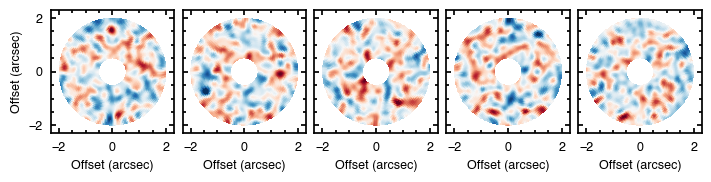

In [28]:
# in on-sky projection

fig, axs = plt.subplots(ncols=5, figsize=(7, 2.0), constrained_layout=True)
for noise_draw, ax in zip(noise, axs):
    im = ax.pcolormesh(r_e[:, None] * np.cos(p_e)[None, :],
                      r_e[:, None] * np.sin(p_e)[None, :], noise_draw,
                       cmap='RdBu_r', vmin=-60, vmax=60)
    ax.set_xlim(-2.3, 2.3)
    ax.set_ylim(-2.3, 2.3)
    ax.set_box_aspect(1)
    if ax == axs[0]:
        ax.set_ylabel('Offset (arcsec)')
    else:
        ax.set_yticklabels([])
    ax.set_xlabel(r'Offset (arcsec)')

Now that we have the fields, we can calculate the structure functions. We'll also consider an _ensemble_ of structure functions which allows us to consider all fields in our calculate of $S_2$, thereby beating down the sampling variance. This is the appropriate way of combining fields, rather than first calculating their individual $S_2$ and then combining.

grid = 'polar', ref = None, S2_i = None
S2 surface (81, 161), lag extent [-120.   120.    -0.5    0.5]
1 realization   sigma = 21.30   ell_r = 0.156   ell_phi(r_mid) = 0.168
24 combined     sigma = 19.92   ell_r = 0.149   ell_phi(r_mid) = 0.149
truth           sigma = 20.00   ell_r = 0.150   ell_phi      = 0.150


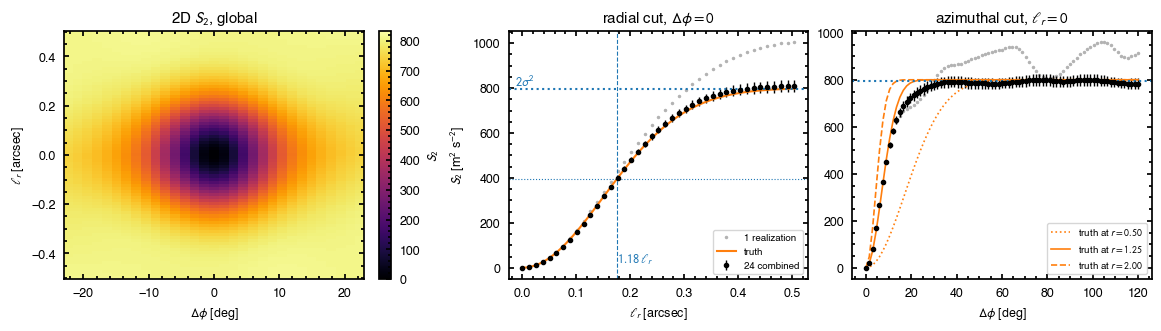

In [3]:
# Lag extents are in PIXELS: 40 px radially is 0.5 arcsec, 80 px
# azimuthally is 120 deg. These labels ride along on the result and are
# picked up by the plotting helpers.
lag_kw = dict(dx=dr, dy=dphi, max_lag_x=40, max_lag_y=80, azimuthal_axis='y',
              x_label=r'$\ell_r$ [arcsec]', y_label=r'$\Delta\phi$ [deg]')

# ref_i defaults to -1, which pools every pair in the field into one
# *global* S_2. The ensemble helper does the same per realization and
# deliberately does NOT average, so combine() is called by hand: it is the
# pair-count-weighted mean, and it attaches the realization scatter.
s2_one = calculate_structure_function(noise[0], **lag_kw)
ens = calculate_structure_function_ensemble(noise, mode='global', **lag_kw)
s2 = ens[0].combine(ens[1:])

print('grid = {!r}, ref = {}, S2_i = {}'.format(s2.grid, s2.ref, s2.S2_i))
print('S2 surface {}, lag extent {}'.format(s2.S2.shape, np.round(s2.extent, 2)))

# Reduce each to scalars. The azimuthal lag comes back in degrees, so the
# conversion to a physical arc length needs a radius -- here the middle of
# the grid, since a global S_2 has pooled every radius together.
r_mid = float(np.mean(r))
for name, obj in [('1 realization', s2_one), ('24 combined  ', s2)]:
    pl = obj.plateau()
    print('{}   sigma = {:5.2f}   ell_r = {:.3f}   ell_phi(r_mid) = {:.3f}'
          .format(name, np.sqrt(pl / 2),
                  obj.half_power_lag('x') / HALF_POWER,
                  np.radians(obj.half_power_lag('y')) * r_mid / HALF_POWER))
print('{}   sigma = {:5.2f}   ell_r = {:.3f}   ell_phi      = {:.3f}'
      .format('truth        ', noise_truth['sigma'], noise_truth['ell0r'],
              noise_truth['ell0phi']))

# combine() attaches the per-cell standard error over realizations on the
# same 2D grid as S2, so the on-axis slices need the same indexing as
# .counts_x / .counts_y.
err_x = s2.combined_error[s2.max_lag_x:, s2.max_lag_y]
err_y = s2.combined_error[s2.max_lag_x, s2.max_lag_y:]

# The exact model, S_2 = 2 sigma^2 [1 - exp(-l^2 / 2 ell^2)], takes the
# *physical* separation l, so an azimuthal lag enters as the arc r * dphi.
model = lambda lag, ell: 2 * noise_truth['sigma']**2 * \
    (1.0 - np.exp(-0.5 * (lag / ell)**2))

fig, axs = plt.subplots(ncols=3, figsize=(11.5, 3.2), constrained_layout=True)

# The two lag axes are incommensurate (arcsec against degrees), so the
# aspect ratio of this panel is a choice and not a property of the field.
# Trimming the azimuthal range to the arc length that matches the radial
# range at r_mid is what makes the isotropy show up as circular contours.
s2.plot_2d(ax=axs[0], cmap='inferno')
axs[0].set(xlim=np.degrees(0.5 / r_mid) * np.array([-1.0, 1.0]),
           title=r'2D $S_2$, global')

plateau = s2.plateau()
axs[1].plot(s2_one.lags_x, s2_one.S2_x, '.', ms=3, color='0.7',
            label='1 realization')
axs[1].errorbar(s2.lags_x, s2.S2_x, err_x, fmt='o', ms=3, lw=1, color='k',
                label='24 combined')
axs[1].plot(s2.lags_x, model(s2.lags_x, noise_truth['ell0r']), '-',
            color='C1', lw=1.5, label='truth')
axs[1].axhline(plateau, ls=':', color='C0')
axs[1].axhline(0.5 * plateau, ls=':', color='C0', lw=0.8)
axs[1].axvline(s2.half_power_lag('x'), ls='--', color='C0', lw=0.8)
axs[1].annotate(r'$2\sigma^2$', (0.02, plateau), va='bottom', color='C0',
                xycoords=('axes fraction', 'data'))
axs[1].annotate(r'$1.18\,\ell_r$', (s2.half_power_lag('x'), 0.03 * plateau),
                color='C0', ha='left')
axs[1].set(xlabel=r'$\ell_r$ [arcsec]', ylabel=r'$S_2$ [m$^2$ s$^{-2}$]',
           title=r'radial cut, $\Delta\phi = 0$')
axs[1].legend(fontsize=7, loc='lower right')

# In global mode the azimuthal cut has pooled every radius, so it lands
# between the models for the inner and outer edge of the grid.
axs[2].plot(s2_one.lags_y, s2_one.S2_y, '.', ms=3, color='0.7')
axs[2].errorbar(s2.lags_y, s2.S2_y, err_y, fmt='o', ms=3, lw=1, color='k')
for rr, ls in zip((r[0], r_mid, r[-1]), (':', '-', '--')):
    axs[2].plot(s2.lags_y,
                model(np.radians(s2.lags_y) * rr, noise_truth['ell0phi']),
                ls, color='C1', lw=1.2,
                label=r'truth at $r = {:.2f}$'.format(rr))
axs[2].axhline(plateau, ls=':', color='C0')
axs[2].set(xlabel=r'$\Delta\phi$ [deg]', title=r'azimuthal cut, $\ell_r = 0$')
axs[2].legend(fontsize=7, loc='lower right');

## Building Intuition - Flocculent Spirals

Now switch on everything the noise field had switched off.

- **anisotropy** — $\ell_{0,\phi}/\ell_{0,r} = 3$, stretching the correlation ellipse along the azimuth. This is the generic signature of a sheared disk: a radial perturbation gets wound into an arc.
- **non-stationarity** — $\alpha_r = \alpha_\phi = 1$, i.e. self-similar, both lengths growing linearly with radius. Because $\ell_\phi$ is an arc length, $\alpha_\phi = 1$ is exactly the case where the azimuthal scale is a *constant number of degrees* at every radius. That is where the $T_4 = \hat\alpha_\phi - 1$ convention in the heuristics comes from: the slope of $\log\ell_\phi[{\rm deg}]$ against $\log r$ is $\alpha_\phi - 1$, so a self-similar field returns zero.
- **pitch** — the ellipse leans out of the azimuthal direction by $\beta = 30^\circ$, which is what turns concentric arcs into arms.

The phases stay random, so these are **flocculent** spirals: many short, incoherent arm segments sharing a pitch angle, rather than a grand design, which would be a *deterministic* pattern added on top with `draw_polar_field(..., mean=...)`.

The pitch is the one parameter the on-axis cuts cannot see, and it is worth being explicit about why. The tilted ellipse has principal axes $(\ell_r, \ell_\phi)$, but a cut at $\Delta\phi = 0$ or at $\ell_r = 0$ samples it along the *grid* directions, i.e. it measures the axis-aligned chords

$$\ell_r^{\rm app} = \left[\frac{\cos^2\beta}{\ell_r^2} + \frac{\sin^2\beta}{\ell_\phi^2}\right]^{-1/2}, \qquad \ell_\phi^{\rm app} = \left[\frac{\sin^2\beta}{\ell_r^2} + \frac{\cos^2\beta}{\ell_\phi^2}\right]^{-1/2},$$

which for $\beta = 30^\circ$ and $\mathcal{A} = 3$ collapses the *apparent* anisotropy to $\ell_\phi^{\rm app}/\ell_r^{\rm app} = 1.53$. Every slice-based measurement — the heuristics, and the stack's `fit_GRF` — therefore returns those apparent lengths, and only the global 2D surface, which retains the antisymmetric off-diagonal ridge, can undo the projection and recover $\beta$ itself. Both claims are checked numerically below.

   r     ell_r [as]   ell_phi [as]   ell_phi [deg]
 0.50       0.050          0.150           17.2
 1.00       0.100          0.300           17.2
 2.00       0.200          0.600           17.2


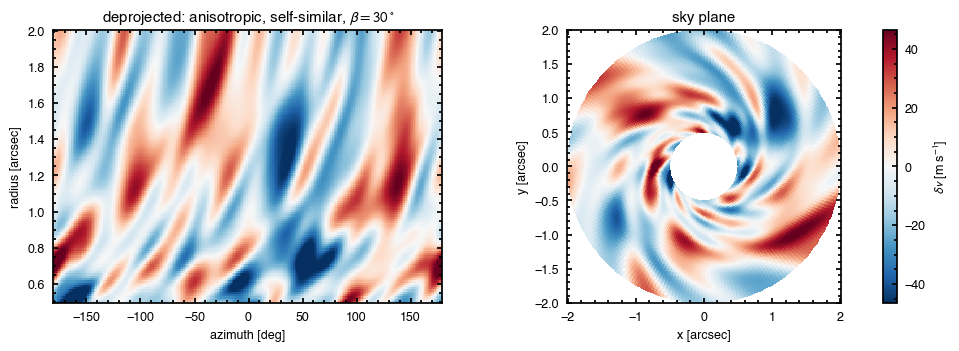

In [4]:
# Same grid, three knobs turned relative to the noise field: anisotropic
# (ell0phi / ell0r = 3), self-similar (alpha = 1, so both lengths grow with
# radius and ell_phi is a fixed number of degrees), and pitched by 30 deg.
spiral_truth = dict(sigma=20.0, ell0r=0.10, ell0phi=0.30,
                    alphar=1.0, alphaphi=1.0, r0=1.0, pitch=30.0)
spiral = draw_polar_field(r, phi, n_realizations=24, rng=7, **spiral_truth)

# What the two power laws mean in the two sets of units.
print('   r     ell_r [as]   ell_phi [as]   ell_phi [deg]')
for rr in (0.5, 1.0, 2.0):
    lr = ell_r(rr, spiral_truth['ell0r'], spiral_truth['alphar'])
    lp = ell_phi(rr, spiral_truth['ell0phi'], spiral_truth['alphaphi'])
    print('{:5.2f}   {:9.3f}   {:12.3f}   {:12.1f}'
          .format(rr, lr, lp, np.degrees(lp / rr)))

plot_polar_field(spiral[0], r'anisotropic, self-similar, $\beta=30^\circ$');

### A *global* $S_2$, and a *stack* of them

The kernel can pool pairs two ways, and the choice is not a detail.

**Global** (`ref_i=-1`, the default) throws every pair in the field into one surface. Best signal-to-noise, and the only mode that preserves the full 2D lag structure — in particular the antisymmetric off-diagonal ridge left by a pitched ellipse, the sole observable that fixes $\beta$ and its sign. The price is that every pair at every radius lands in the same surface: a correlation length that grows outwards is smeared into a radially averaged one, and the azimuthal axis mixes radii for which the same $\Delta\phi$ is a different physical distance.

**Stack** (`ref_rs=...`) anchors every pair to a reference annulus and returns one $S_2$ per radius. This is what makes $\alpha_r$, $\alpha_\phi$ and the anisotropy profile measurable, and it is what the heatmaps and the heuristics are built on. Two costs: fewer pairs per ring, so each ring is noisier; and the reference-annulus kernel mirror-fills the azimuthal lag, $S_2[\ell_r, +\Delta\phi] = S_2[\ell_r, -\Delta\phi]$, which averages the pitch ridge away — hence `fit_GRF(pitch=True)` raises on a stack.

`collapse()` maps a stack back down to one $S_2$; with the rings tiling the field its on-axis cuts match a true global exactly, though the off-axis surface does not, for the mirror-fill reason above.

The panels below show the three signatures of this field. The radial cuts fan out as $\ell_r \propto r$. The azimuthal cuts, in **degrees**, collapse onto a single curve — that is $\alpha_\phi = 1$, and the reason $T_4$ is defined as a slope in degrees. Convert the same cuts to an arc length $r\,\Delta\phi$ and they fan out again. The global $S_2$ (dashed) is one curve through the middle of each family.

stack of 12 rings at r = [0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8]
S2_x_stack (12, 41), S2_y_stack (12, 81), ref of ring 0 = 0.70
global S2 (81, 161), ref = None


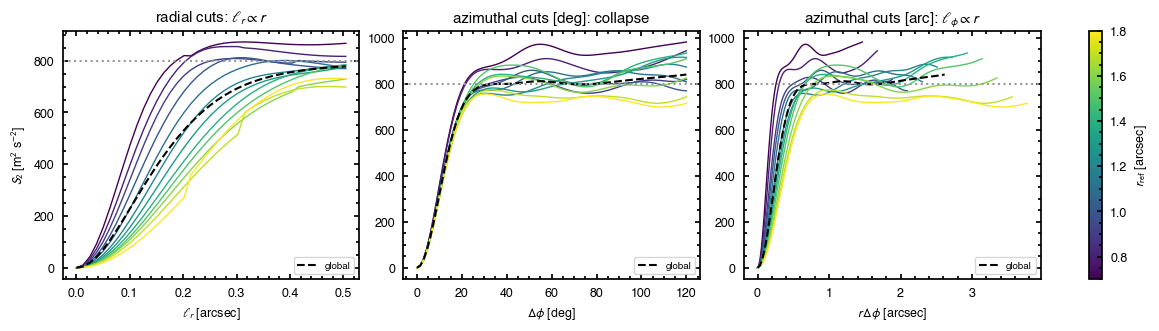

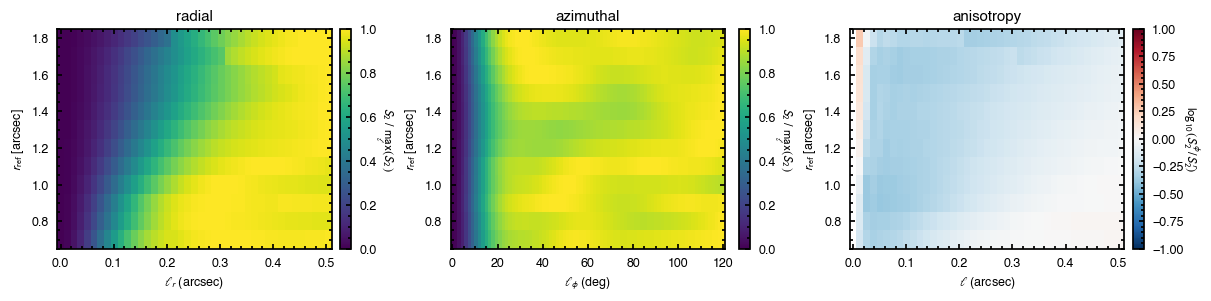

In [5]:
ref_rs = np.arange(0.7, 1.85, 0.1)

# One radius-resolved stack and one global S_2 per realization, each then
# pooled over realizations. x_axis maps axis 0 onto a physical radius so
# ref_rs can be given in arcsec; y_grid is just carried for plot_gridded.
stacks = calculate_structure_function_ensemble(
    spiral, mode='stack', ref_rs=ref_rs, x_axis=r, y_grid=phi, **lag_kw)
globals_ = calculate_structure_function_ensemble(spiral, mode='global',
                                                **lag_kw)
stack = stacks[0].combine(stacks[1:])
s2_global = globals_[0].combine(globals_[1:])

print('stack of {} rings at r = {}'.format(len(stack), np.round(stack.ref_rs, 2)))
print('S2_x_stack {}, S2_y_stack {}, ref of ring 0 = {:.2f}'
      .format(stack.S2_x_stack.shape, stack.S2_y_stack.shape, stack[0].ref))
print('global S2 {}, ref = {}'.format(s2_global.S2.shape, s2_global.ref))

cmap = plt.get_cmap('viridis')
cols = cmap(np.linspace(0.0, 1.0, len(stack)))

fig, axs = plt.subplots(ncols=3, figsize=(11.5, 3.2), constrained_layout=True)
for i, (rr, c) in enumerate(zip(stack.ref_rs, cols)):
    axs[0].plot(stack.lags_x, stack.S2_x_stack[i], color=c, lw=1)
    axs[1].plot(stack.lags_y, stack.S2_y_stack[i], color=c, lw=1)
    axs[2].plot(np.radians(stack.lags_y) * rr, stack.S2_y_stack[i],
                color=c, lw=1)
for ax, x, y in ((axs[0], s2_global.lags_x, s2_global.S2_x),
                 (axs[1], s2_global.lags_y, s2_global.S2_y),
                 (axs[2], np.radians(s2_global.lags_y) * r_mid,
                  s2_global.S2_y)):
    ax.plot(x, y, 'k--', lw=1.5, label='global')
    ax.axhline(2 * spiral_truth['sigma']**2, color='0.6', ls=':')
    ax.legend(fontsize=7, loc='lower right')
axs[0].set(xlabel=r'$\ell_r$ [arcsec]', ylabel=r'$S_2$ [m$^2$ s$^{-2}$]',
           title=r'radial cuts: $\ell_r \propto r$')
axs[1].set(xlabel=r'$\Delta\phi$ [deg]',
           title=r'azimuthal cuts [deg]: collapse')
axs[2].set(xlabel=r'$r\,\Delta\phi$ [arcsec]',
           title=r'azimuthal cuts [arc]: $\ell_\phi \propto r$')
fig.colorbar(plt.cm.ScalarMappable(
    cmap=cmap, norm=plt.Normalize(stack.ref_rs[0], stack.ref_rs[-1])),
    ax=axs, label=r'$r_{\rm ref}$ [arcsec]')

# The same information as heatmaps, which is how it is read off real data:
# row-normalizing takes out the amplitude so the rollover is what is left.
# The anisotropy panel is < 1 (blue) wherever structure is azimuthally
# elongated, and asymptotes to 1 / A^2 at small lag.
fig, axs = plt.subplots(ncols=3, figsize=(12, 2.9), constrained_layout=True)
stack.plot_radial_heatmap(ax=axs[0], normalize='row_max')
stack.plot_azimuthal_heatmap(ax=axs[1], normalize='row_max')
stack.plot_anisotropy_heatmap(ax=axs[2], log=True, cmap='RdBu_r',
                              vmin=-1, vmax=1)
for ax, title in zip(axs, ('radial', 'azimuthal', 'anisotropy')):
    ax.set(ylabel=r'$r_{\rm ref}$ [arcsec]', title=title)

### Heuristics

Before fitting anything, a stack can be reduced to six model-free numbers. `calculate_heuristics()` returns

| | quantity | built from |
| :-- | :-- | :-- |
| $T_{1a}$ | $\hat\sigma$ | plateau of the collapsed stack, $\hat\sigma = \sqrt{T_{1a}/2}$ |
| $T_{1b}$ | $\hat\ell_r$ | half-power lag of the radial cut, averaged over rings |
| $T_{1c}$ | $\hat\ell_\phi$ | half-power lag of the azimuthal cut, as an arc length |
| $T_2$ | $\hat{\mathcal{A}}$ | $\exp\langle\log(s_\phi/\ell_r)\rangle$, the anisotropy |
| $T_3$ | $\hat\alpha_r$ | slope of $\log\ell_r$ against $\log r$ |
| $T_4$ | $\hat\alpha_\phi - 1$ | slope of $\log\ell_\phi[{\rm deg}]$ against $\log r$ |

Every cross-ring average is weighted by `reliability_weights('neff')`, the effective number of independent patches in a ring, and restricted to $r \in [r_{\rm min}, r_{\rm max}]$ — useful for dropping the inner rings, where the azimuthal sampling is sparsest and the deprojection worst, and the outer rings, whose radial lag window runs off the edge of the grid.

Three conventions decide whether the numbers below "make sense", and the comparison table checks all three:

1. $T_{1b}$ and $T_{1c}$ are **half-power lags**, not $\ell_0$ — for a Gaussian correlation they are the $1.18\times$ larger crossing point, so they map onto `ell0r` / `ell0phi` only up to that factor. $T_2$, a ratio of the two, is unaffected.
2. $T_4$ is the slope of $\log\ell_\phi$ in **degrees**, so it equals $\alpha_\phi - 1$ and not $\alpha_\phi$. It is kept that way deliberately: measured natively on the deprojected grid it never multiplies by the deprojection-uncertain ring radius. $T_3 - T_4 = 1$ exactly when the anisotropy is radius-independent.
3. Being slice-based, $T_{1b}$, $T_{1c}$ and $T_2$ see the **apparent** axis-aligned lengths of the pitched ellipse, so the anisotropy of this field reads $1.53$ rather than $3$.

$T_3$ is the least stable of the six. It is a log-log slope across a factor $\sim\!2.5$ in radius, so a few percent of per-ring noise in $\ell_r$ moves it by $\sim\!0.1$; quote it with the ring selection used.

In [6]:
# Drop the innermost and outermost rings, whose radial lag window runs off
# the edge of the grid.
T1a, T1b, T1c, T2, T3, T4 = stack.calculate_heuristics(r_min=0.8, r_max=1.7)


def apparent_lengths(lr, lp, pitch):
    """Axis-aligned chords of a correlation ellipse tilted by ``pitch``.

    The on-axis S_2 cuts sample the ellipse along the grid directions, not
    along its principal axes, so once it is tilted every slice-based length
    is shorter than the corresponding axis and the anisotropy looks weaker.
    """
    b = np.radians(pitch)
    M_rr = np.cos(b)**2 / lr**2 + np.sin(b)**2 / lp**2
    M_pp = np.sin(b)**2 / lr**2 + np.cos(b)**2 / lp**2
    return 1.0 / np.sqrt(M_rr), 1.0 / np.sqrt(M_pp)


lr_app, lp_app = apparent_lengths(spiral_truth['ell0r'],
                                  spiral_truth['ell0phi'],
                                  spiral_truth['pitch'])

# The expectation for T1b / T1c: the neff-weighted mean over the selected
# rings of the *apparent* length, times the 1.18 half-power factor.
sel = (stack.ref_rs >= 0.8) & (stack.ref_rs <= 1.7)
rings = stack.ref_rs[sel]
weights = np.asarray(stack.reliability_weights(kind='neff'))[sel]

print('                    measured    expected')
for name, got, exp in [
        ('T1a  sigma       ', T1a, spiral_truth['sigma']),
        ('T1b  1.18 ell_r  ', T1b, HALF_POWER * np.average(
            ell_r(rings, lr_app, spiral_truth['alphar']), weights=weights)),
        ('T1c  1.18 arc_phi', T1c, HALF_POWER * np.average(
            ell_phi(rings, lp_app, spiral_truth['alphaphi']), weights=weights)),
        ('T2   anisotropy A', T2, lp_app / lr_app),
        ('T3   alphar      ', T3, spiral_truth['alphar']),
        ('T4   alphaphi - 1', T4, spiral_truth['alphaphi'] - 1.0)]:
    print('{}  {:9.3f}   {:9.3f}'.format(name, got, exp))

print('\ntrue ellipse at r0:            ell_r = {:.3f}, ell_phi = {:.3f}, '
      'A = {:.2f}'.format(spiral_truth['ell0r'], spiral_truth['ell0phi'],
                          spiral_truth['ell0phi'] / spiral_truth['ell0r']))
print('as the axes see it at beta={:.0f}:  ell_r = {:.3f}, ell_phi = {:.3f}, '
      'A = {:.2f}'.format(spiral_truth['pitch'], lr_app, lp_app,
                          lp_app / lr_app))

# How much the two slopes move with the ring selection.
print('\nring selection            T3      T4')
for lo, hi in [(None, None), (0.8, 1.7), (0.7, 1.6)]:
    T = stack.calculate_heuristics(r_min=lo, r_max=hi)
    print('r_min={!s:<5} r_max={!s:<5}  {:6.3f}  {:6.3f}'.format(lo, hi, T[4], T[5]))

                    measured    expected
T1a  sigma            20.123      20.000
T1b  1.18 ell_r        0.166       0.165
T1c  1.18 arc_phi      0.255       0.253
T2   anisotropy A      1.546       1.528
T3   alphar            1.163       1.000
T4   alphaphi - 1      0.019       0.000

true ellipse at r0:            ell_r = 0.100, ell_phi = 0.300, A = 3.00
as the axes see it at beta=30:  ell_r = 0.113, ell_phi = 0.173, A = 1.53

ring selection            T3      T4
r_min=None  r_max=None    0.981  -0.011
r_min=0.8   r_max=1.7     1.163   0.019
r_min=0.7   r_max=1.6     1.042   0.030


### GRF Fit

The heuristics stop at "how big" and "how elongated". `fit_GRF` fits the full anisotropic Gaussian-random-field model — the same one `draw_polar_field` drew from — so each parameter comes with an uncertainty and the correlation-length power laws are constrained by every lag at once rather than by one crossing point per ring.

The sampled set is $\theta = \{\sigma,\, \ell_{0,r},\, \ell_{0,\phi},\, \alpha_r\}$, with $\alpha_\phi$ **tied to $\alpha_r$** by default (a radius-independent anisotropy). `fit_alphaphi=True` frees it, which is what makes $T_3$ and $T_4$ separately testable. The anisotropy $\mathcal{A} = \ell_\phi/\ell_r$ is derived, not fit. Positive parameters are sampled in log; `method='lsq'` gives a fast point estimate with a Gauss-Newton covariance, and `method='mcmc'` starts `emcee` from that solution for the full posterior — worth using with `jitter=True`, since the default residual weighting is a heuristic rather than a real uncertainty.

Two fits are run below, and the difference between them is the point of the pitch discussion above:

- the **stack** fits the on-axis slices ring by ring. It measures $\sigma$, the radial scalings and the *apparent* lengths, and `pitch=True` raises here.
- the **global** surface fit (`r_axis=...`, `pitch=True`) fits the full 2D $S_2$, off-diagonal ridge included, and recovers the true ellipse along with $\beta$.

The formal errors are tiny because they come from 24 pooled realizations of an idealised field with a heuristic weighting. On real data the error budget is dominated by the deprojection, and by everything in a residual map that is not a Gaussian random field.

              truth  apparent       stack (slices)     global (surface)
     sigma  20.0000   20.0000   20.2042 +/- 0.0205   20.1346 +/- 0.0022
     ell0r   0.1000    0.1134    0.1073 +/- 0.0005    0.0998 +/- 0.0001
   ell0phi   0.3000    0.1732    0.1722 +/- 0.0008    0.3144 +/- 0.0007
    alphar   1.0000    1.0000    1.1231 +/- 0.0099    1.0683 +/- 0.0058
  alphaphi   1.0000    1.0000    1.1146 +/- 0.0124    1.0461 +/- 0.0111
     pitch  30.0000    0.0000                    -   30.2610 +/- 0.0418


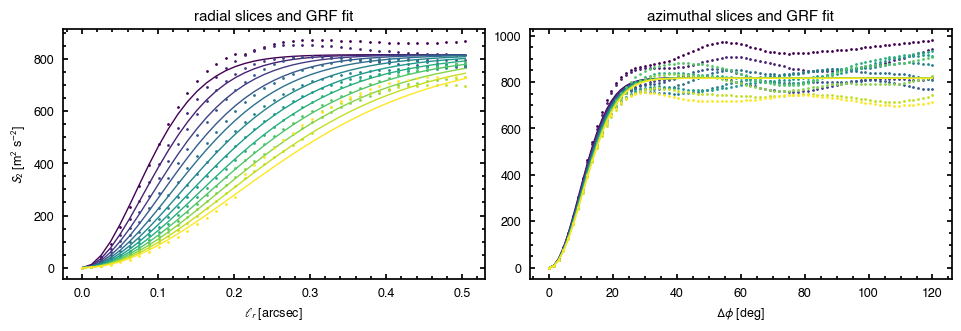

In [7]:
# Slice fit, ring by ring. fit_alphaphi frees the azimuthal slope instead
# of tying it to alphar, so that alphar and alphaphi are separate answers.
p_stack, e_stack, _, _ = stack.fit_GRF(method='lsq', r0=1.0,
                                       fit_alphaphi=True)

# Surface fit on the global S_2, which is the only place the pitch survives.
# It needs the radial grid the field was built on.
p_glob, e_glob, _, _ = s2_global.fit_GRF(method='lsq', r0=1.0, r_axis=r,
                                         pitch=True, fit_alphaphi=True)

truth_app = dict(spiral_truth, ell0r=lr_app, ell0phi=lp_app, pitch=0.0)
print('{:>10s} {:>8s} {:>9s}   {:>18s}   {:>18s}'
      .format('', 'truth', 'apparent', 'stack (slices)', 'global (surface)'))
for key in ('sigma', 'ell0r', 'ell0phi', 'alphar', 'alphaphi', 'pitch'):
    row = '{:>10s} {:8.4f} {:9.4f}'.format(key, spiral_truth.get(key, 0.0),
                                           truth_app.get(key, 0.0))
    for p, e in ((p_stack, e_stack), (p_glob, e_glob)):
        row += '   {:>18s}'.format(
            '-' if key not in p else
            '{:.4f} +/- {:.4f}'.format(p[key], e[key]) if key in e else
            '{:.4f} (tied)'.format(p[key]))
    print(row)

# Goodness of fit, by eye: the forward model on the same lag axes as the
# measurement. grf_s2_slices is the model fit_GRF fits.
fig, axs = plt.subplots(ncols=2, figsize=(9.5, 3.2), constrained_layout=True)
for i, (rr, c) in enumerate(zip(stack.ref_rs, cols)):
    m = grf_s2_slices(rr, stack.lags_x, stack.lags_y, r0=1.0,
                      **{k: p_stack[k] for k in ('sigma', 'alphar', 'ell0r',
                                                 'alphaphi', 'ell0phi')})
    axs[0].plot(stack.lags_x, stack.S2_x_stack[i], '.', ms=2, color=c)
    axs[0].plot(stack.lags_x, m['S2_r'], '-', lw=1, color=c)
    axs[1].plot(stack.lags_y, stack.S2_y_stack[i], '.', ms=2, color=c)
    axs[1].plot(stack.lags_y, m['S2_phi'], '-', lw=1, color=c)
axs[0].set(xlabel=r'$\ell_r$ [arcsec]', ylabel=r'$S_2$ [m$^2$ s$^{-2}$]',
           title='radial slices and GRF fit')
axs[1].set(xlabel=r'$\Delta\phi$ [deg]',
           title='azimuthal slices and GRF fit');